<a href="https://colab.research.google.com/github/aldo02032004/naufaldo.github.io/blob/main/daily_report_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Report

One day's export, for either issue:

- **Politics**: a treemap of the day's top keywords, where the local LLM writes each tile's topic
  and headline, and a pie of author sentiment (one vote per author). `daily_overview()`.
- **Environment**: the environment map with issue and island bars. `env_daily()`.

### **Mounting Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### **Inputing the Requirement**

In [93]:
import datetime as dt, os

TIMESTAMP       = dt.datetime.now().strftime('%d%m%Y')
ISSUES          = 'Politics' # 'Politics' or 'Environment'
ROBJ            = 'Bakom RI & Syahganda Nainggolan' # Changes this based on your research object
ROBJ_TERMS      = ['bakom', 'badan', 'komunikasi', 'pemerintah', 'pco', 'kepresidenan', 'syahganda', 'nainggolan'] # Politics: words naming ROBJ, left out of the treemap keywords
FOCUS_TERMS     = r'bakom|badan komunikasi|syahganda' # top-post table: a post must mention one of these in its title or content
ZIP_SOURCES     = [ # zip di Drive: path atau link share, bisa lebih dari satu
    'https://drive.google.com/file/d/1WMAm0mUZito8YrdY0pfNTWQVbNF_m6n7/view?usp=drive_link',
    'https://drive.google.com/file/d/1SBihMO3efZwDjBpUrTSghjtXQ9awwaMD/view?usp=drive_link',
    'https://drive.google.com/file/d/12cNT5iLH8JVbs2AnzXTgpJUGCPXlWmNs/view?usp=drive_link',
    'https://drive.google.com/file/d/1cSSkk8nMeuAOrA1rqm0IhnuJvJN3HfH0/view?usp=drive_link',]
OUT_DIR         = f'/content/drive/MyDrive/model_result/daily_{ISSUES.lower()}_{TIMESTAMP}';os.makedirs(OUT_DIR,exist_ok=True) # To upload the result directly
N_TILES         = 6   # Politics: tiles in the treemap
N_DOCS          = 4    # Politics: representative posts per tile given to the LLM
N_POSTS         = 5    # posts per sentiment in the top-post table
MODEL_REPO      = 'faizonly5953/gemma2-9b-cpt-sahabatai-v1-instruct-GGUF' # Change the model based on the provider that you use
MODEL_FILE      = 'gemma2-9b-cpt-sahabatai-v1-instruct.q4_k_m.gguf' # Change the model based on the provider that you use

### **Notebook Set Up**

Politics also installs llama-cpp for the local LLM. A GPU whose driver supports CUDA 12 or newer
gets the CUDA build; anything else (CPU, or an older GPU) gets the CPU build, which is slower
but gives the same labels.

In [80]:
%pip install -q "great[all] @ git+https://github.com/azmkto/GREAT-Tools.git"

HAS_GPU = False
if ISSUES == 'Politics':
    import re, shutil, subprocess

    smi = subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout if shutil.which('nvidia-smi') else ''
    cuda = re.search(r'CUDA Version: (\d+)\.(\d+)', smi)
    major, minor = (int(cuda[1]), int(cuda[2])) if cuda else (0, 0)
    HAS_GPU = major >= 12
    CU_TAG = f'cu12{min(minor, 4) if major == 12 else 4}' if HAS_GPU else 'cpu'   # abetlen publishes cu121..cu124 + cpu
    print(f'Detected: CUDA {major}.{minor} -> {CU_TAG}' if cuda else f'Detected: no GPU -> {CU_TAG}')
    !pip install -q llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/{CU_TAG}

    if HAS_GPU:
        # the cu12x wheel links CUDA 12 runtime libs; newer Colab images ship CUDA 13 only, so load the 12 libs first
        !pip install -q nvidia-cuda-runtime-cu12 nvidia-cublas-cu12
        import ctypes, glob, site
        for lib in ['libcudart.so.12', 'libcublasLt.so.12', 'libcublas.so.12']:
            ctypes.CDLL(glob.glob(f'{site.getsitepackages()[0]}/nvidia/*/lib/{lib}')[0], mode=ctypes.RTLD_GLOBAL)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Detected: CUDA 13.0 -> cu124


In [81]:
import json

import pandas as pd
from tqdm.auto import tqdm

from great import classify_issue, resolve_frame
from great.viz import checks, prep
from great.viz.environment import env_daily
from great.viz.overview import author_sentiment, daily_overview, keyword_tiles, representative_posts

### **Accessing File**

In [82]:
import zipfile

frames, names = [], []
for i, source in enumerate(ZIP_SOURCES):
    zip_path = source
    if source.startswith('http'):
        import gdown
        zip_path = gdown.download(source, f'/content/input_{i}.zip', fuzzy=True, quiet=True)

    with zipfile.ZipFile(zip_path) as z:
        # ambil semua excel di dalam zip, skip file sampah bawaan mac/excel
        files = [n for n in z.namelist()
                 if n.lower().endswith(('.xlsx', '.xls'))
                 and not n.startswith('__MACOSX')
                 and not os.path.basename(n).startswith('~$')]
        frames += [pd.read_excel(z.open(n), header=1) for n in files]
        names += files

df = pd.concat(frames, ignore_index=True)
df = df[~df['Link'].duplicated() | df['Link'].isna()]   # post yang sama bisa ada di dua ekspor (mis. keyword Bakom & Syahganda)

print(f'{len(names)} file excel: {names}')
print(f'{len(df):,} rows after dropping duplicate links')

df1, start_date, end_date = prep.prepare_data(df)

print(f'{start_date} - {end_date}')

1 file excel: ['report_17736_all_all_20261009_20261009_2887_Badan_Komunikasi_Presiden.xlsx']
09 Oct 2026 - 09 Oct 2026


# Cleaning

In [83]:
before = len(df1)
df1 = df1.drop_duplicates(['Author', 'Mentions'], keep='first').reset_index(drop=True)
print(f'{before:,} rows -> {len(df1):,} after dropping same author + same content')

162 rows -> 141 after dropping same author + same content


### **Checking Dataframe Info**

In [84]:
checks.frame_info(df1, 'Main Dataframe')
checks.composition(df1)


Main Dataframe Info:

Number of Rows: 141
Columns: ['No', 'Type', 'Headline', 'Mentions', 'Date', 'Link', 'Media', 'Sentiment', 'Author', 'Followers', 'Retweeted', 'Favourited', 'Location']

Data Types:
No                     int64
Type                  object
Headline              object
Mentions              object
Date          datetime64[ns]
Link                  object
Media                 object
Sentiment             object
Author                object
Followers              int64
Retweeted              int64
Favourited             int64
Location              object 

Sentiment Breakdown:
           Count  Share (%)
Sentiment                  
positive      56       39.7
negative      44       31.2
neutral       41       29.1 

Platform Breakdown:
           Count  Share (%)
Media                      
Instagram     51       36.2
Twitter       40       28.4
News          29       20.6
Youtube       14        9.9
Facebook       4        2.8
Tiktok         3        2.1 



### **Topic and Headline from the LLM**

Politics only. `keyword_tiles()` files each post under its most distinctive keyword and keeps the
`N_TILES` biggest. For each tile the LLM reads the keyword and its `N_DOCS` most repeated
headlines (`representative_posts()`), and writes the tile's topic and headline. If a call
fails, the tile keeps the keyword as its topic and its top headline, cut to 15 words.

In [85]:
if ISSUES == 'Politics':
    from huggingface_hub import hf_hub_download
    from llama_cpp import Llama

    model_path = hf_hub_download(repo_id=MODEL_REPO, filename=MODEL_FILE)
    llm = Llama(model_path=model_path, n_gpu_layers=-1 if HAS_GPU else 0, n_ctx=4096, n_batch=512, verbose=False)

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)


In [86]:
FIELDS = ['topic', 'headline']
SCHEMA = {'type': 'object', 'properties': {f: {'type': 'string'} for f in FIELDS}, 'required': FIELDS}

PROMPT = """You are a media analyst at a socio-political think tank, summarising today's public discourse.

These posts all use the keyword "{keyword}":
{documents}

Return JSON with exactly these fields:
1. topic    - the topic in at most 3 words: the person, institution, or issue the posts are about.
2. headline - one news-style headline of at most 7 words saying what happened, grounded in the posts.

Answer in Indonesian. Output only JSON.
"""

if ISSUES == 'Politics':
    df1['Keyword'] = keyword_tiles(df1, exclude=ROBJ_TERMS, n_tiles=N_TILES)

    records = []
    for keyword, count in tqdm(df1['Keyword'].value_counts().items(), total=N_TILES, desc='tiles'):
        docs = representative_posts(df1[df1['Keyword'] == keyword], n=N_DOCS)
        try:
            r = llm.create_chat_completion(
                messages=[{'role': 'user', 'content': PROMPT.format(keyword=keyword, documents='\n'.join(f'- {d}' for d in docs))}],
                response_format={'type': 'json_object', 'schema': SCHEMA},
                temperature=0, max_tokens=200,
            )
            out = json.loads(r['choices'][0]['message']['content'])
        except Exception as e:
            print(f'{keyword} failed: {type(e).__name__}: {e}')
            out = {}
        records.append({
            'Keyword': keyword,
            'Count': count,
            'Topic': (out.get('topic') or keyword).strip(),
            'Headline': (out.get('headline') or ' '.join(docs[0].split()[:15])).strip(),
        })

    tiles = pd.DataFrame(records)
    tiles.to_excel(f'{OUT_DIR}/daily_politics_topics_{TIMESTAMP}.xlsx', index=False)
    display(tiles)

tiles:   0%|          | 0/6 [00:00<?, ?it/s]

,Keyword,Count,Topic,Headline
0,bodong,16,Wapres Gibran,Syahganda Nainggolan Desak Gibran Diganti
1,presiden,14,Rocky Gerung,Rocky Gerung Buka Suara Usai Jadi Wantimpres
2,kepala,13,Gibran Rakabuming,Gibran Rakabuming Dipertanyakan Asal Bisnisnya
3,prabowo,12,Prabowo Subianto,Prabowo Minta Bahasa Pemerintah Sederhana
4,rakyat,8,Jokowi dan Rakyat,"Rakyat Kritik Jokowi, Bakom Dipesan Prabowo"
5,politik,8,Komunikasi Pemerintah,Bakom RI Fokus Pulihkan Nama Baik


### **Visualize**

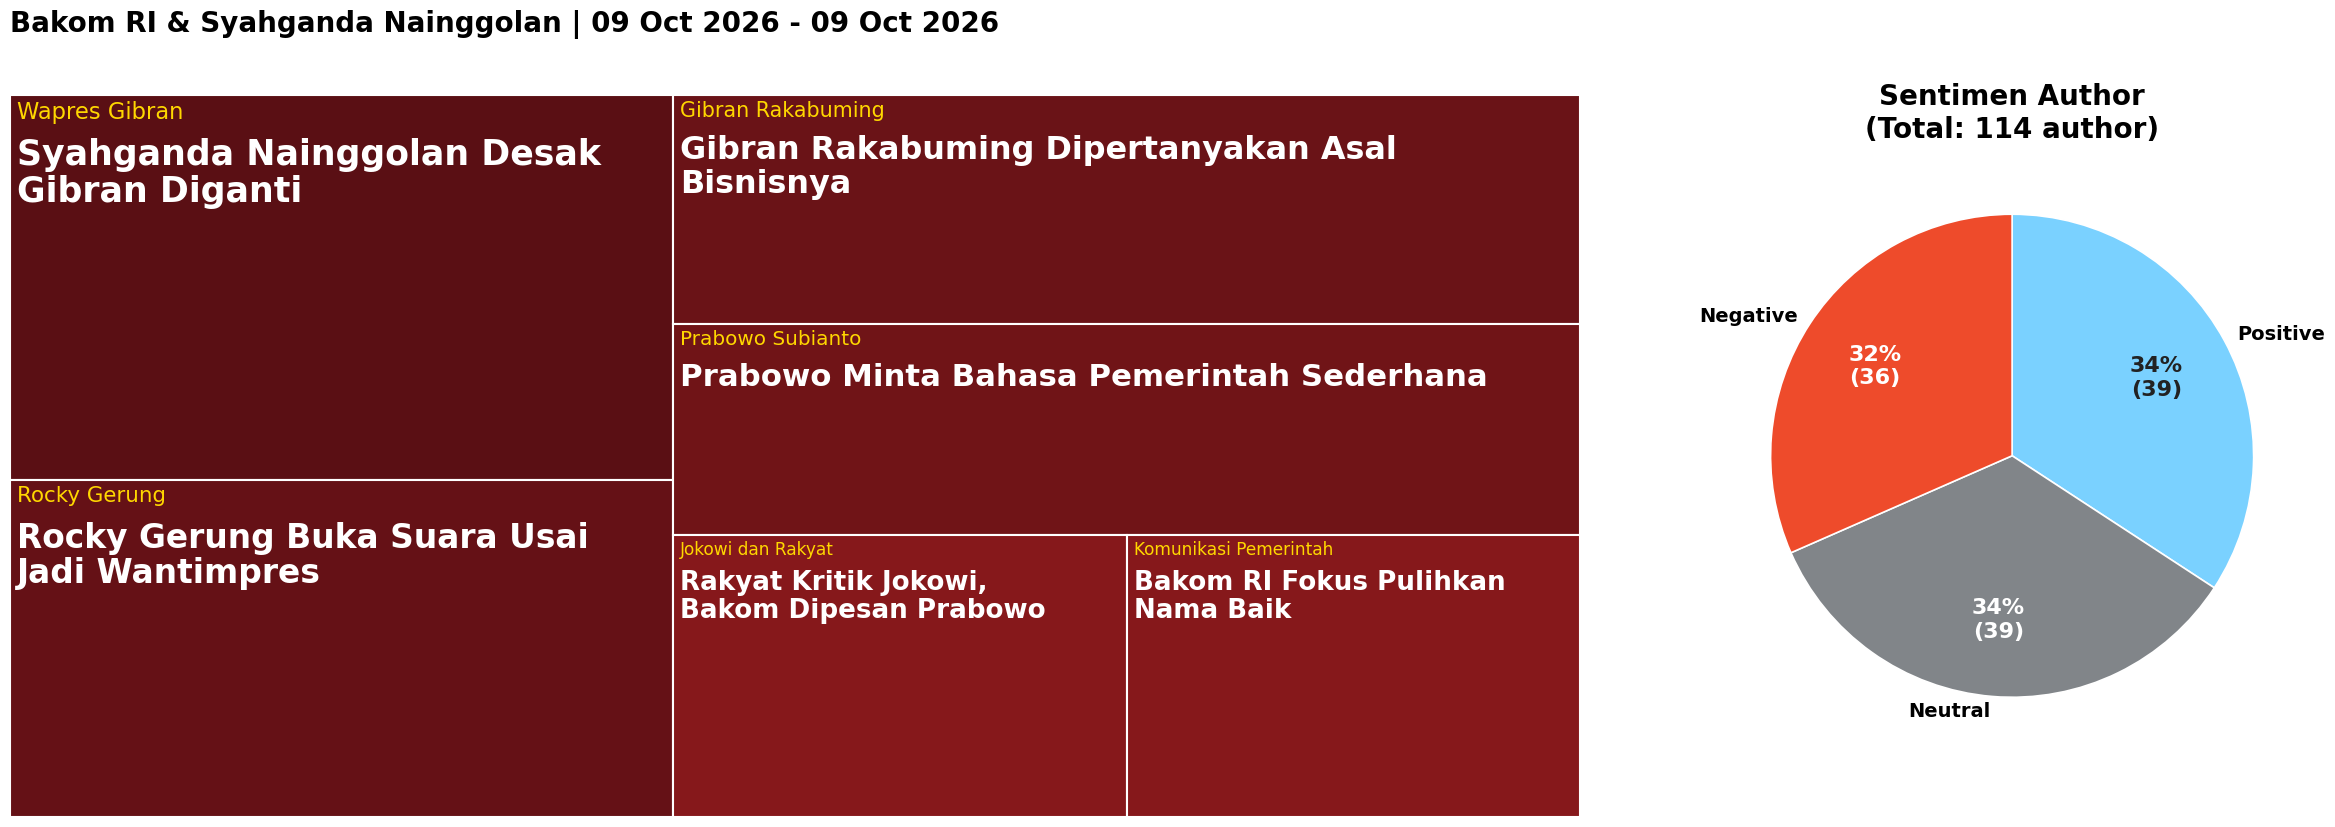

In [101]:
if ISSUES == 'Politics':
    fig = daily_overview(tiles, author_sentiment(df1), ROBJ, start_date, end_date)
else:
    df1['Isu_Inti'] = df1['Mentions'].map(classify_issue)
    df1[['Provinsi', 'Pulau']] = resolve_frame(df1)
    fig = env_daily(df1, start_date=start_date, end_date=end_date)

fig.savefig(f'{OUT_DIR}/daily_{ISSUES.lower()}_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')

In [100]:
JUNK_TITLES  = r'(?:#\w+.*){3}|Halaman \d+|Anda mencari|^Berita .* Terkini|^Kumpulan Artikel'   # titles to skip: hashtag-only posts, tag/search/index pages
FOREIGN      = r'[åäöÅÄÖ]'   # ponytail: Swedish 'bakom' (= behind) leaks in from the export keyword; a letter check, not real language detection
SOCIAL_NOISE = r'^RT\s+(@\w+:?\s*)?|^@\w+\s+|^.+? on TikTok\s+|https?://\S+|Follow the .+? on WhatsApp\W*'   # retweet marker, reply handle, TikTok account prefix, links, channel promo

SUMMARY_SCHEMA = {'type': 'object', 'properties': {'summary': {'type': 'string'}}, 'required': ['summary']}

SUMMARY_PROMPT = """You are a media analyst at a socio-political think tank, summarising today's public discourse.

Key actors:
- President Prabowo Subianto, including his flagship programs (MBG, Koperasi Desa Merah Putih, Sekolah Rakyat, swasembada pangan dan energi, hilirisasi, Danantara).
- The DPR and Prof. Sufmi Dasco Ahmad.
- Dr. Syahganda Nainggolan and GREAT Institute, including his past statements resurfacing.
- Badan Komunikasi Pemerintah (Bakom) and its head.

Post:
Title: {title}
Content: {content}

Return JSON with one field, "summary": one complete sentence of at most 20 words saying who did or said what.

Who starts the sentence:
- A key actor, if one acts or speaks in the post.
- Otherwise the main actor in the post.
- "Warganet menilai", if the post is written by an ordinary user (their own opinion, or their comment on someone else).

Content:
- Say what was questioned, denied, demanded, or announced. Never stop at a fragment such as "X pertanyakan asalnya".
- Keep the key number (rupiah, percent, count, date) if the post states one.
- Keep the post's stance (support, criticism, denial, clarification) without softening it.
- Use only what the post states. Attribute words to a person only if the post quotes them or clearly says they said it.

Wording:
- Paraphrase informal posts into standard Indonesian, without slang. Keep news headlines close to their original meaning.
- Keep person and institution names exactly as written, including abbreviations: Bakom stays Bakom, Komdigi stays Komdigi. Do not rename or expand them.

Answer in Indonesian.
"""

STORY = 'Keyword' if 'Keyword' in df1 else 'Headline'   # Politics: one post per tile, so one story doesn't fill every slot

text = df1['Mentions'].str.cat(df1['Headline'], sep=' ', na_rep='')   # search both: social posts only have Mentions, news has both
pool = df1[text.str.contains(FOCUS_TERMS, case=False)
           & ~text.str.contains(FOREIGN)
           & ~df1['Headline'].str.contains(JUNK_TITLES, case=False, na=False)].copy()   # na=False keeps headline-less social posts
mention = pool['Mentions'].str.replace(SOCIAL_NOISE, '', regex=True).str.strip()   # strip before slicing so a retweet and its original share one title
pool['Title'] = (pool['Headline'].fillna(mention.str.slice(0, 120))   # social posts: first 120 chars of the cleaned mention stand in for a title
                 .str.replace(r'\s+[-|]\s+[^-|]{1,25}$', '', regex=True).str.strip())   # drop " - Site Name" so copies of one story group together
pool['Story'] = pool[STORY].fillna(pool['Title'])   # posts outside the tiles count as their own story

top = (pool.groupby('Title')
       .agg(Sentiment=('Sentiment', lambda s: s.mode()[0]),   # one label per story; a tie goes to the first alphabetically (negative)
            Count=('Author', 'nunique'), Reach=('Followers', 'max'), Media=('Media', 'first'),
            Content=('Mentions', 'first'), Story=('Story', 'first'))
       .reset_index()
       .sort_values(['Count', 'Reach'], ascending=False))

links = pool.groupby('Title')['Link'].agg(lambda s: '\n'.join(s.dropna().unique()[:3]))   # up to 3 links from copies of the same story


def summarise(post):
    """One-line LLM summary of a post; None on failure so the caller falls back to the title."""
    try:
        r = llm.create_chat_completion(
            messages=[{'role': 'user', 'content': SUMMARY_PROMPT.format(title=post.Title, content=str(post.Content)[:1500])}],
            response_format={'type': 'json_object', 'schema': SUMMARY_SCHEMA},
            temperature=0.2, max_tokens=200,
        )
        return json.loads(r['choices'][0]['message']['content']).get('summary')
    except Exception as e:
        print(f'{post.Title[:40]} failed: {type(e).__name__}: {e}')


records = []
for sentiment in ['positive', 'negative']:
    picks = top[top['Sentiment'] == sentiment].drop_duplicates('Story').head(N_POSTS)

    for post in tqdm(picks.itertuples(), total=len(picks), desc=sentiment):
        summary = summarise(post) if ISSUES == 'Politics' else None
        records.append({
            'Sentiment': sentiment,
            'Media': post.Media,
            'Story': post.Story,
            'Headline': post.Title,
            'Summary': (summary or ' '.join(post.Title.split()[:20])).strip(),
            'Link': links[post.Title],
            'Count': post.Count,
        })

top_posts = pd.DataFrame(records).sort_values(['Sentiment', 'Count'], ascending=False, kind='stable', ignore_index=True)   # positive before negative ('p' > 'n'), then Count high to low; stable keeps the Reach order on ties
pd.set_option('display.max_colwidth', None)
display(top_posts.style.format({'Link': lambda u: '<br>'.join(f'<a href="{x}" target="_blank">{x}</a>' for x in u.split('\n'))}))

positive:   0%|          | 0/5 [00:00<?, ?it/s]

negative:   0%|          | 0/5 [00:00<?, ?it/s]

,Sentiment,Media,Story,Headline,Summary,Link,Count
0,positive,Twitter,rakyat,"Ini Bakom yang bicara. - Kalau Jokowi ini, enggak ada gunanya berarti untuk bangsa ini. Karena dia menciptakan utang,",Syahganda Nainggolan mempertanyakan sumber modal yang memungkinkan bisnis keluarga Jokowi berkembang hingga bernilai besar.,https://twitter.com/web/statuses/2108366107522617560https://twitter.com/web/statuses/2108353258066772103https://twitter.com/web/statuses/2108353175610908763,5
1,positive,News,"Sinyal Ekonomi Menguat, Inflasi Terkendali dan Manufaktur Kembali Ekspansi","Sinyal Ekonomi Menguat, Inflasi Terkendali dan Manufaktur Kembali Ekspansi","Menko Perekonomian Airlangga Hartarto menyatakan bahwa inflasi September 2026 tercatat 3,28 persen secara tahunan, masih berada dalam sasaran nasional 2,5±1 persen.",https://kataindonesia.com/sinyal-ekonomi-menguat-inflasi-terkendali-dan-manufaktur-kembali-ekspansi/https://katainvestor.com/sinyal-ekonomi-menguat-inflasi-terkendali-dan-manufaktur-kembali-ekspansi/,2
2,positive,Tiktok,politik,"Kepala Badan Komunikasi (Bakom) Pemerintah RI, M. Qodari, menegaskan tidak takut menghadapi serangan berupa tudingan yan","Kepala Badan Komunikasi (Bakom) Pemerintah RI, M. Qodari, membantah tuduhan rekrutmen 30 kader partai politik, pengelolaan anggaran iklan media Rp60 miliar, dan keterlibatan Deputi II Timothy Ivan Triono dalam kasus suap KPK.",https://www.tiktok.com/@tribunnews/photo/7691273931096968466,1
3,positive,Tiktok,prabowo,Presiden Prabowo Subianto meminta Badan Komunikasi Pemerintah (Bakom) menggunakan bahasa yang sederhana agar program dan,Presiden Prabowo Subianto meminta Badan Komunikasi Pemerintah (Bakom) menggunakan bahasa yang sederhana agar program dan kebijakan pemerintah lebih mudah dipahami masyarakat.,https://www.tiktok.com/@tribunnews/photo/7693026692217982216,1
4,positive,Twitter,"""Satu server, itu sama dalam ideologi. Saya belum lihat ada perbedaan gitu loh..."" Syahganda Nainggolan menilai ada ala","""Satu server, itu sama dalam ideologi. Saya belum lihat ada perbedaan gitu loh..."" Syahganda Nainggolan menilai ada ala",Syahganda Nainggolan menilai ada alasan mendasar di balik sikap Rocky Gerung yang belakangan tidak terlalu vokal menyerang Presiden Prabowo Subianto.,https://twitter.com/web/statuses/2108462268203896835,1
5,negative,Twitter,bodong,Syahganda Nainggolan DESAK Si GIBLER @gibran_tweet DIGANTI RAKYAT INDONESIA 🇲🇨 MALU DUNIA MENYAKSIKAN WAPRES BODONG LUL,Syahganda Nainggolan mendesak Gibran Rakabuming Raka diganti karena dianggap bodong dan lulusan SMP.,https://twitter.com/web/statuses/2108441976735666663https://twitter.com/web/statuses/2108440036685537482https://twitter.com/web/statuses/2108436921567572420,15
6,negative,Twitter,kepala,"Keluarga Jokowi Disebut Putar Bisnis Triliunan Rupiah, Kepala Bakom Pertanyakan Asalnya",Kepala Badan Komunikasi Pemerintah mempertanyakan asal informasi yang menyebut Keluarga Jokowi memutar bisnis triliunan rupiah.,https://twitter.com/web/statuses/2108287233984008439https://twitter.com/web/statuses/2108324209864909228https://twitter.com/web/statuses/2108410986889925035,3
7,negative,Twitter,syahganda nainggolan (kepala bakom) mengklarifikasi video lamanya yang mendesak wapres gibran diganti dengan 3 orang ka,syahganda nainggolan (kepala bakom) mengklarifikasi video lamanya yang mendesak wapres gibran diganti dengan 3 orang ka,"Syahganda Nainggolan, Kepala Badan Komunikasi Pemerintah, mengklarifikasi video lama yang mendesak Wakil Presiden Gibran diganti dengan tiga orang, dengan mengatakan pernyataan itu dibuat sebelum dilantik menjadi kepala Bakom.",https://twitter.com/web/statuses/2108320286684942680https://twitter.com/web/statuses/2108267068420448311,2
8,negative,Twitter,"Syahganda Nainggolan, Jumhur Hidayat, Saiq Iqbal dari dulu juga gtu. Galak kalau di luar istana, ketika gabung istana","Syahganda Nainggolan, Jumhur Hidayat, Saiq Iqbal dari dulu juga gtu. Galak kalau di luar istana, ketika gabung istana","Warganet menilai Sy